# PART 1: Building up a basic predictive model

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Dataset.csv")

C:\Users\preri\AppData\Local\Temp\ipykernel_2972\362287225.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Dataset.csv")


In [4]:
df.head()

,index,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,2,1,2,2,09/06/2020,1,2,55,?,...,2,2,2,2,2,2,2,2,3,2.0
1,5,2,1,1,2,9999-99-99,2,1,40,2,...,2,2,2,2,2,2,2,2,3,2.0
2,8,2,1,1,2,9999-99-99,2,2,37,2,...,2,2,1,2,2,1,2,2,3,2.0
3,9,2,1,1,2,9999-99-99,2,2,25,2,...,2,2,2,2,2,2,2,2,3,2.0
4,11,2,1,2,2,9999-99-99,2,2,24,?,...,2,2,2,2,2,2,2,2,3,2.0


In [5]:
df.shape

(200031, 22)

Removing Index and Date_Died Columns

In [7]:
df.drop(columns= ['index','DATE_DIED'],inplace= True)

In [8]:
df.shape

(200031, 20)

Missing values before conversion to NaN

In [10]:
missing_values = df.isnull().sum()
missing_values

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

In [11]:
df.replace("?", np.nan, inplace=True)

In [12]:
cols = ['INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE',           
'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'SEX', 'PATIENT_TYPE']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [13]:
df[cols] = df[cols].where(df[cols].isin([1, 2]))

Missing values after conversion to NaN

In [15]:
missing_values = df.isnull().sum()
missing_values

USMER                        0
MEDICAL_UNIT                 0
SEX                          0
PATIENT_TYPE                 0
INTUBED                   7325
PNEUMONIA                 5144
AGE                          0
PREGNANT                118792
DIABETES                  1195
COPD                      1064
ASTHMA                    1066
INMSUPR                   1280
HIPERTENSION              1106
OTHER_DISEASE             2074
CARDIOVASCULAR            1143
OBESITY                   1113
RENAL_CHRONIC             1074
TOBACCO                   1126
CLASIFFICATION_FINAL         0
ICU                       7488
dtype: int64

In [16]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,2,2,1.0,2.0,55,NaN,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0
1,2,1,1,2,2.0,1.0,40,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0
2,2,1,1,2,2.0,2.0,37,2.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,3,2.0
3,2,1,1,2,2.0,2.0,25,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0
4,2,1,2,2,2.0,2.0,24,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0


In [17]:
df.dtypes

USMER                     int64
MEDICAL_UNIT              int64
SEX                       int64
PATIENT_TYPE              int64
INTUBED                 float64
PNEUMONIA               float64
AGE                       int64
PREGNANT                float64
DIABETES                float64
COPD                    float64
ASTHMA                  float64
INMSUPR                 float64
HIPERTENSION            float64
OTHER_DISEASE           float64
CARDIOVASCULAR          float64
OBESITY                 float64
RENAL_CHRONIC           float64
TOBACCO                 float64
CLASIFFICATION_FINAL      int64
ICU                     float64
dtype: object

In [18]:
Before_dropping_null_values = df.shape
Before_dropping_null_values

(200031, 20)

In [19]:
df.dropna(inplace=True)

In [20]:
After_dropping_null_values = df.shape
After_dropping_null_values

(76832, 20)

In [21]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
1,2,1,1,2,2.0,1.0,40,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0
2,2,1,1,2,2.0,2.0,37,2.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,3,2.0
3,2,1,1,2,2.0,2.0,25,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,2.0
6,2,1,1,2,2.0,1.0,80,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,3,1.0
12,2,1,1,2,1.0,1.0,58,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,7,1.0


In [22]:
df['AGE'].describe()

count    76832.000000
mean        52.836670
std         20.279334
min          0.000000
25%         41.000000
50%         55.000000
75%         67.000000
max        115.000000
Name: AGE, dtype: float64

In [23]:
Q1 = df['AGE'].quantile(0.25)
Q3 = df['AGE'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR: {IQR}")
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")

outliers = df[(df['AGE'] < lower) | (df['AGE'] > upper)]
print(f"Number of outliers: {len(outliers)}")

IQR: 26.0
Lower bound: 2.0
Upper bound: 106.0
Number of outliers: 1737


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

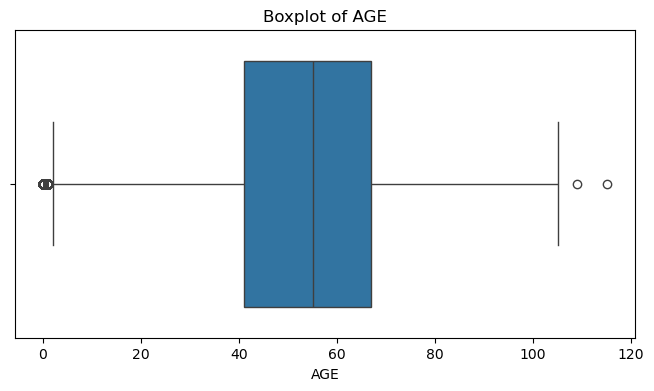

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['AGE'])
plt.title("Boxplot of AGE")
plt.show()

In [26]:
df = df[(df['AGE'] >= lower) & (df['AGE'] <= upper)]

In [27]:
df.shape

(75095, 20)

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
df['AGE_ORIGINAL'] = df['AGE']

In [30]:
scaler = StandardScaler()
df.loc[:, 'AGE'] = scaler.fit_transform(df[['AGE']])

C:\Users\preri\AppData\Local\Temp\ipykernel_2972\1265023535.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.74493368 -0.90402467 -1.54038864 ...  0.47476393 -1.6464493
  0.10355162]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, 'AGE'] = scaler.fit_transform(df[['AGE']])


In [31]:
df.shape

(75095, 21)

Plot the distribution of unique classes of the target variable.

In [33]:
df['ICU'].unique()

array([2., 1.])

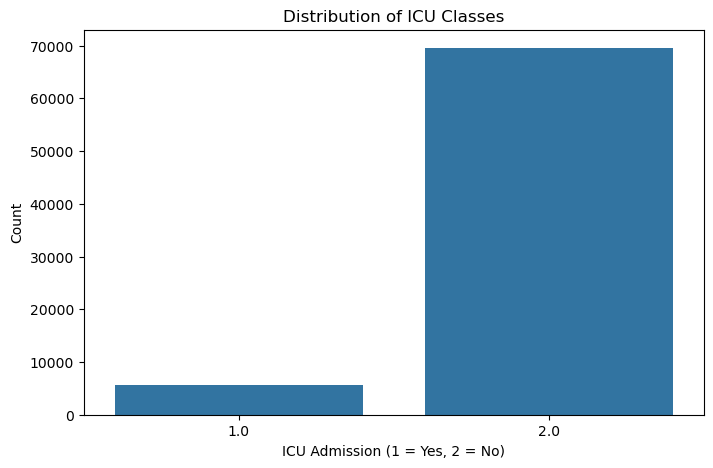

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(x='ICU', data=df)
plt.title('Distribution of ICU Classes')
plt.xlabel('ICU Admission (1 = Yes, 2 = No)')
plt.ylabel('Count')
plt.show()

Plot the count of number of ICU cases against age

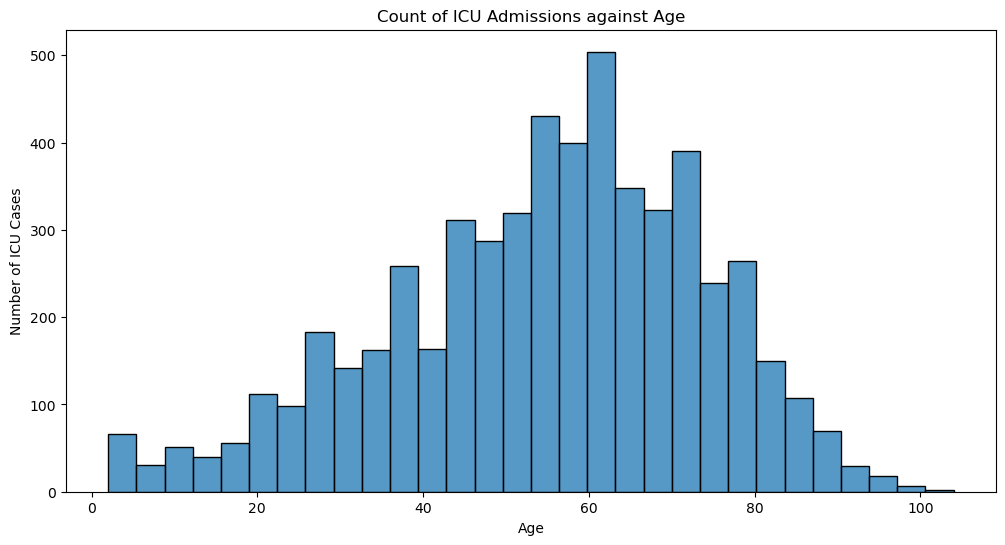

In [38]:
icu_admitted = df[df['ICU'] == 1]

plt.figure(figsize=(12, 6))
sns.histplot(data=icu_admitted, x='AGE_ORIGINAL', bins=30, kde=False)
plt.title("Count of ICU Admissions against Age")
plt.xlabel("Age")
plt.ylabel("Number of ICU Cases")
plt.show()

Plot the count of target variable against CLASSIFICATION_FINAL

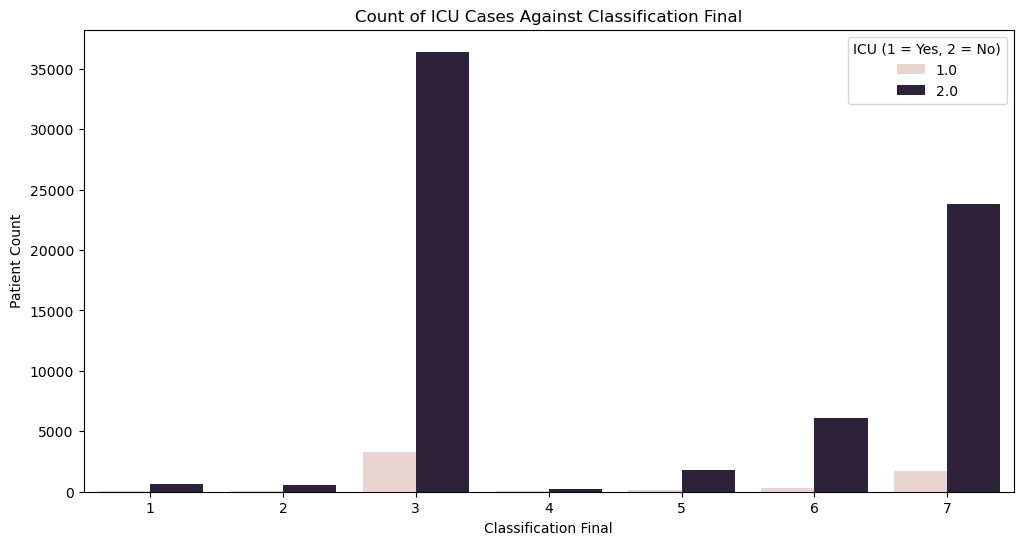

In [40]:
plt.figure(figsize=(12, 6))
sns.countplot(x='CLASIFFICATION_FINAL', hue='ICU', data=df)
plt.title('Count of ICU Cases Against Classification Final')
plt.xlabel('Classification Final')
plt.ylabel('Patient Count')
plt.legend(title="ICU (1 = Yes, 2 = No)")
plt.show()

Show the scatter matrix plot and the correlation matrices. 

<Figure size 1200x1000 with 0 Axes>

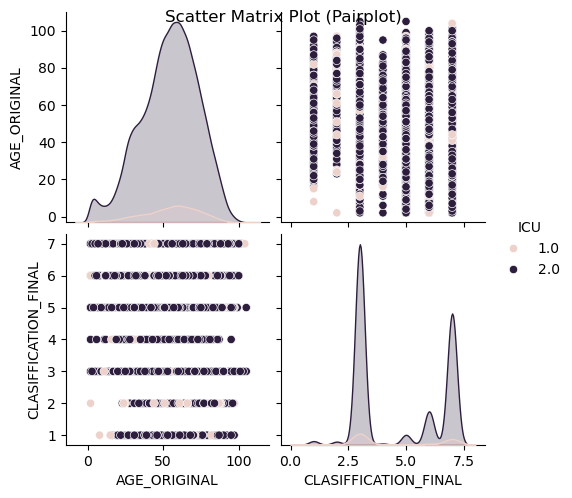

In [42]:
plt.figure(figsize=(12, 10))
features = ['AGE_ORIGINAL', 'CLASIFFICATION_FINAL', 'ICU']
sns.pairplot(df[features], hue='ICU') 
plt.suptitle('Scatter Matrix Plot (Pairplot)')
plt.show()

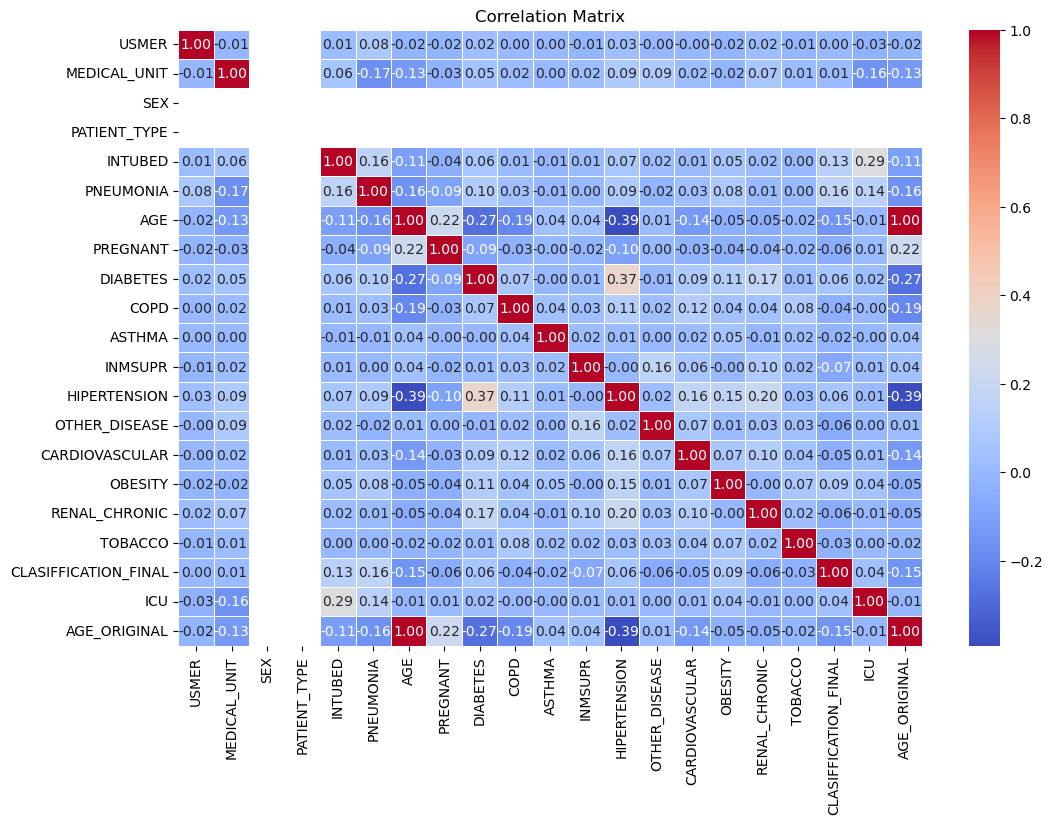

In [43]:
correlation_matrix = df.corr(numeric_only=True)  
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [44]:
df[['SEX', 'PATIENT_TYPE']].corr()

,SEX,PATIENT_TYPE
SEX,NaN,NaN
PATIENT_TYPE,NaN,NaN


In [45]:
df[['SEX', 'PATIENT_TYPE']].nunique()

SEX             1
PATIENT_TYPE    1
dtype: int64

Count of number of ICU cases against intubed patients

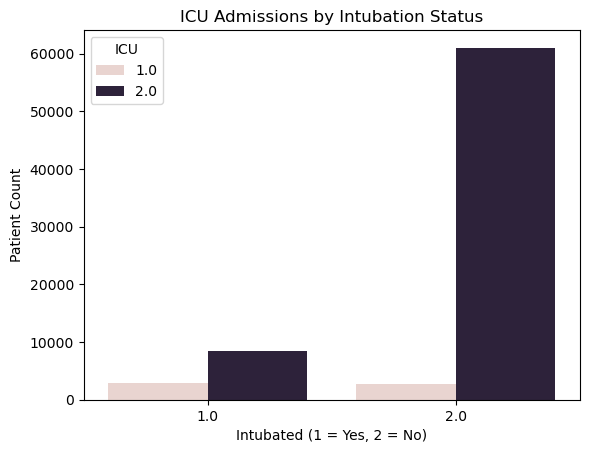

In [47]:
sns.countplot(data=df, x='INTUBED', hue='ICU')
plt.title('ICU Admissions by Intubation Status')
plt.xlabel('Intubated (1 = Yes, 2 = No)')
plt.ylabel('Patient Count')
plt.legend(title='ICU')
plt.show()

Correlation between ICU and other health features

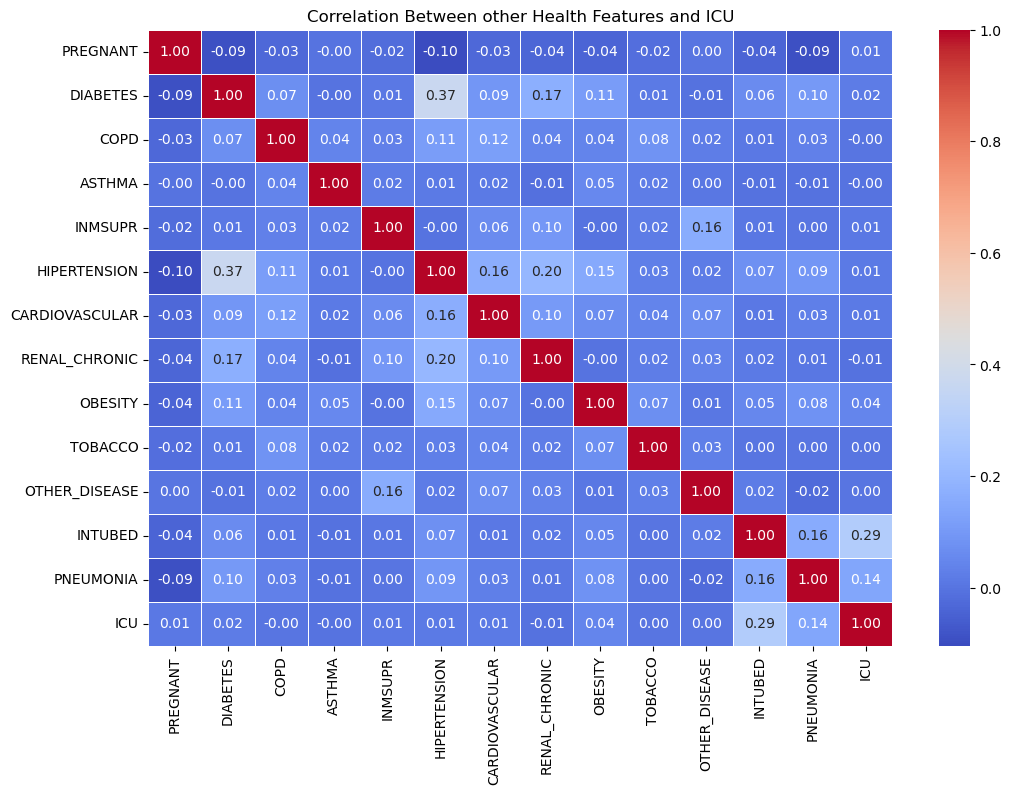

In [49]:
other_cols = ['PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'OBESITY', 'TOBACCO', 
              'OTHER_DISEASE', 'INTUBED', 'PNEUMONIA', 'ICU']
plt.figure(figsize=(12, 8))
sns.heatmap(df[other_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Between other Health Features and ICU")
plt.show()

Select the predictors that would have impact in predicting ICU.

In [51]:
predictors = ['INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE',           
'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'AGE', 'CLASIFFICATION_FINAL']

df[predictors + ['ICU']].corr()['ICU']

INTUBED                 0.289771
PNEUMONIA               0.140546
PREGNANT                0.010185
DIABETES                0.018841
COPD                   -0.000056
ASTHMA                 -0.004849
INMSUPR                 0.011079
HIPERTENSION            0.012742
OTHER_DISEASE           0.000931
CARDIOVASCULAR          0.012954
OBESITY                 0.043958
RENAL_CHRONIC          -0.005463
TOBACCO                 0.000856
AGE                    -0.009251
CLASIFFICATION_FINAL    0.036769
ICU                     1.000000
Name: ICU, dtype: float64

In [52]:
final_predictors = ['INTUBED', 'PNEUMONIA', 'INMSUPR', 'OBESITY', 'AGE', 'CLASIFFICATION_FINAL']

df[final_predictors + ['ICU']].corr()['ICU']

INTUBED                 0.289771
PNEUMONIA               0.140546
INMSUPR                 0.011079
OBESITY                 0.043958
AGE                    -0.009251
CLASIFFICATION_FINAL    0.036769
ICU                     1.000000
Name: ICU, dtype: float64

Build up a first linear model with appropriate predictors and evaluate it. Split the data into
a training and test sets. Evaluate your model by using a cross-validation procedure.

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
x = df[['INTUBED', 'PNEUMONIA', 'INMSUPR', 'OBESITY', 'AGE', 'CLASIFFICATION_FINAL']]
y = df['ICU'].replace({2: 0, 1: 1})

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
model = LogisticRegression(max_iter=1000) 
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [58]:
train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)

print("\nTrain Accuracy:", train_score)
print("Test Accuracy:", test_score)


Train Accuracy: 0.9253612091350956
Test Accuracy: 0.9285571609294894


In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [60]:
y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9285571609294894

Confusion Matrix:
 [[13946     0]
 [ 1073     0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      1.00      0.96     13946
         1.0       0.00      0.00      0.00      1073

    accuracy                           0.93     15019
   macro avg       0.46      0.50      0.48     15019
weighted avg       0.86      0.93      0.89     15019



C:\Users\preri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\preri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\preri\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
from sklearn.model_selection import cross_val_score

In [62]:
cv_scores = cross_val_score(model, x, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.92402956 0.92602703 0.92602703 0.92596045 0.92596045]
Average CV accuracy: 0.9256009055196751


Use different performance metrics to evaluate the performance of your model. You might
have noticed that the data is imbalanced. The number of positive examples is less than
8% of the total dataset. Choose appropriate performance metrics to evaluate the
performance of your model.

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score,roc_auc_score, roc_curve

Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC Score: 0.7581735181726775


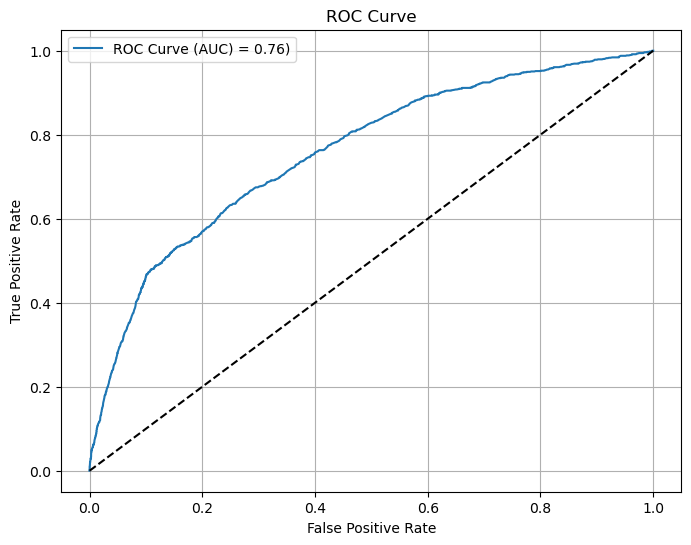

In [65]:
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

y_probability = model.predict_proba(x_test)[:, 1]

auc_score = roc_auc_score(y_test, y_probability)
print("AUC Score:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve (AUC) = {:.2f})'.format(auc_score))
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Balance your data using data balancing technique. Train your model again and evaluate
its performance. Did you achieve better prediction accuracies with more balanced data?

In [67]:
balanced_model = LogisticRegression(max_iter=1000, class_weight='balanced')
balanced_model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Confusion Matrix:
 [[12017  1929]
 [  520   553]]

Precision: 0.22280419016921837
Recall: 0.5153774464119292
F1 Score: 0.3111111111111111
AUC Score: 0.7604508416099429


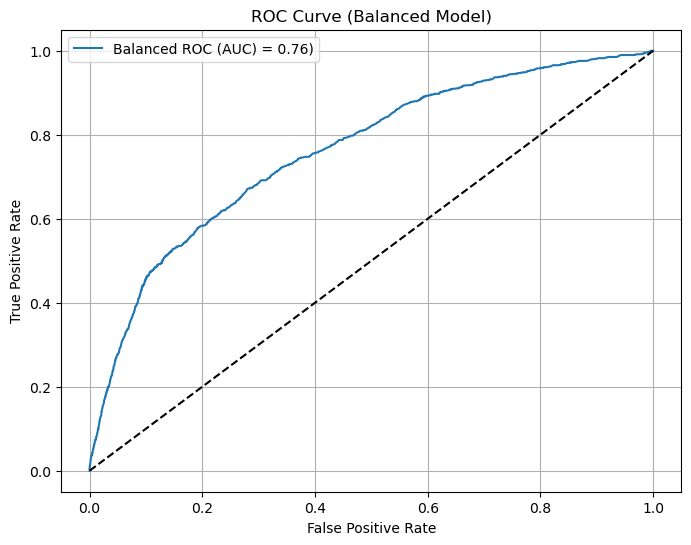

In [68]:
y_predict_balanced = balanced_model.predict(x_test)
y_probability_balanced = balanced_model.predict_proba(x_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_balanced))
print("\nPrecision:", precision_score(y_test, y_predict_balanced, zero_division=0))
print("Recall:", recall_score(y_test, y_predict_balanced, zero_division=0))
print("F1 Score:", f1_score(y_test, y_predict_balanced, zero_division=0))
print("AUC Score:", roc_auc_score(y_test, y_probability_balanced))

fpr, tpr, thresholds = roc_curve(y_test, y_probability_balanced)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Balanced ROC (AUC) = {:.2f})'.format(roc_auc_score(y_test, y_probability_balanced)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Model)')
plt.legend()
plt.grid(True)
plt.show()

# PART 2: Improved model

In [70]:
pip install pyspark findspark

Note: you may need to restart the kernel to use updated packages.


In [71]:
import os
os.environ["JAVA_HOME"] = "C:\\Program Files\\Java\\jre1.8.0_441"  

In [72]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Improved Model").getOrCreate()

In [73]:
df = spark.read.csv("Dataset.csv", header=True)

In [74]:
df.show(5)

+-----+-----+------------+---+------------+----------+-------+---------+---+--------+--------+----+------+-------+------------+-------------+--------------+-------+-------------+-------+--------------------+---+
|index|USMER|MEDICAL_UNIT|SEX|PATIENT_TYPE| DATE_DIED|INTUBED|PNEUMONIA|AGE|PREGNANT|DIABETES|COPD|ASTHMA|INMSUPR|HIPERTENSION|OTHER_DISEASE|CARDIOVASCULAR|OBESITY|RENAL_CHRONIC|TOBACCO|CLASIFFICATION_FINAL|ICU|
+-----+-----+------------+---+------------+----------+-------+---------+---+--------+--------+----+------+-------+------------+-------------+--------------+-------+-------------+-------+--------------------+---+
|    2|    2|           1|  2|           2|09/06/2020|      1|        2| 55|       ?|       1|   2|     2|      2|           2|            2|             2|      2|            2|      2|                   3|2.0|
|    5|    2|           1|  1|           2|9999-99-99|      2|        1| 40|       2|       2|   2|     2|      2|           2|            2|           

In [75]:
df.printSchema()

root
 |-- index: string (nullable = true)
 |-- USMER: string (nullable = true)
 |-- MEDICAL_UNIT: string (nullable = true)
 |-- SEX: string (nullable = true)
 |-- PATIENT_TYPE: string (nullable = true)
 |-- DATE_DIED: string (nullable = true)
 |-- INTUBED: string (nullable = true)
 |-- PNEUMONIA: string (nullable = true)
 |-- AGE: string (nullable = true)
 |-- PREGNANT: string (nullable = true)
 |-- DIABETES: string (nullable = true)
 |-- COPD: string (nullable = true)
 |-- ASTHMA: string (nullable = true)
 |-- INMSUPR: string (nullable = true)
 |-- HIPERTENSION: string (nullable = true)
 |-- OTHER_DISEASE: string (nullable = true)
 |-- CARDIOVASCULAR: string (nullable = true)
 |-- OBESITY: string (nullable = true)
 |-- RENAL_CHRONIC: string (nullable = true)
 |-- TOBACCO: string (nullable = true)
 |-- CLASIFFICATION_FINAL: string (nullable = true)
 |-- ICU: string (nullable = true)



In [76]:
from pyspark.sql.functions import col, when, count

missing_values = {}

for column in df.columns:
    null_count = df.filter(col(column).isNull()).count()
    missing_values[column] = null_count

for col_name in df.columns:
    print(f"{col_name}: {missing_values[col_name]}")

index: 0
USMER: 0
MEDICAL_UNIT: 0
SEX: 0
PATIENT_TYPE: 0
DATE_DIED: 0
INTUBED: 0
PNEUMONIA: 0
AGE: 0
PREGNANT: 0
DIABETES: 0
COPD: 0
ASTHMA: 0
INMSUPR: 0
HIPERTENSION: 0
OTHER_DISEASE: 0
CARDIOVASCULAR: 0
OBESITY: 0
RENAL_CHRONIC: 0
TOBACCO: 0
CLASIFFICATION_FINAL: 0
ICU: 0


In [77]:
from pyspark.sql.functions import trim, when, col
from pyspark.sql.types import DoubleType, IntegerType

cols = ['INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 
        'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'SEX', 'PATIENT_TYPE']

for c in cols:
    df = df.withColumn(c, when(trim(col(c)) == '?', None).otherwise(trim(col(c))))
    df = df.withColumn(c, col(c).cast(DoubleType()))
    df = df.withColumn(c, col(c).cast(IntegerType()))
    df = df.withColumn(c, when(col(c).isin(1, 2), col(c)).otherwise(None))

In [78]:
missing_values = {}

for column in df.columns:
    null_count = df.filter(col(column).isNull()).count()
    missing_values[column] = null_count

for col_name in df.columns:
    print(f"{col_name}: {missing_values[col_name]}")

index: 0
USMER: 0
MEDICAL_UNIT: 0
SEX: 0
PATIENT_TYPE: 0
DATE_DIED: 0
INTUBED: 7325
PNEUMONIA: 5144
AGE: 0
PREGNANT: 118792
DIABETES: 1195
COPD: 1064
ASTHMA: 1066
INMSUPR: 1280
HIPERTENSION: 1106
OTHER_DISEASE: 2074
CARDIOVASCULAR: 1143
OBESITY: 1113
RENAL_CHRONIC: 1074
TOBACCO: 1126
CLASIFFICATION_FINAL: 0
ICU: 7488


In [79]:
from pyspark.ml.feature import Imputer

df = df.withColumn("AGE", col("AGE").cast(DoubleType()))
imputer = Imputer(inputCols=["AGE"], outputCols=["AGE"]).setStrategy("mean")
df = imputer.fit(df).transform(df)

In [80]:
binary_cols = ['INTUBED', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR',
               'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'ICU', 'SEX', 'PATIENT_TYPE']

for c in binary_cols:
    mode_row = df.filter(col(c).isNotNull()).groupBy(c).count().orderBy("count", ascending=False).first()
    mode_value = mode_row[0]
    df = df.fillna({c: mode_value})

In [81]:
missing_values = {}

for column in df.columns:
    null_count = df.filter(col(column).isNull()).count()
    missing_values[column] = null_count

for col_name in df.columns:
    print(f"{col_name}: {missing_values[col_name]}")

index: 0
USMER: 0
MEDICAL_UNIT: 0
SEX: 0
PATIENT_TYPE: 0
DATE_DIED: 0
INTUBED: 0
PNEUMONIA: 0
AGE: 0
PREGNANT: 0
DIABETES: 0
COPD: 0
ASTHMA: 0
INMSUPR: 0
HIPERTENSION: 0
OTHER_DISEASE: 0
CARDIOVASCULAR: 0
OBESITY: 0
RENAL_CHRONIC: 0
TOBACCO: 0
CLASIFFICATION_FINAL: 0
ICU: 0


In [181]:
final_predictors = ['INTUBED', 'PNEUMONIA', 'INMSUPR', 'OBESITY', 'AGE', 'CLASIFFICATION_FINAL']
label = 'ICU'

In [183]:
df = df.withColumn("CLASIFFICATION_FINAL", col("CLASIFFICATION_FINAL").cast(IntegerType()))

In [189]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=predictors, outputCol="features")
df_1 = assembler.transform(df)

In [199]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="ICU", outputCol="label")
df_1 = indexer.fit(df_1).transform(df_1)
train_data, test_data = df_1.randomSplit([0.8, 0.2], seed=42)

In [207]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
model = rf.fit(train_data)
rf_predictions = model.transform(test_data)

In [209]:
rf_results = rf_predictions.select("label", "prediction", "probability").toPandas()

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

y_true = rf_results["label"].astype(int)
y_prediction = rf_results["prediction"].astype(int)
y_probability = rf_results["probability"].apply(lambda x: float(x[1]))  

print("Precision:", precision_score(y_true, y_prediction, zero_division=0))
print("Recall:", recall_score(y_true, y_prediction, zero_division=0))
print("F1 Score:", f1_score(y_true, y_prediction, zero_division=0))
print("AUC Score:", roc_auc_score(y_true, y_probability))

Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC Score: 0.7763712537391692


In [211]:
cluster_features = ['INTUBED', 'PNEUMONIA', 'CLASIFFICATION_FINAL', 'AGE', 'OBESITY', 'INMSUPR']

assembler = VectorAssembler(inputCols=cluster_features, outputCol="features_cluster")
df_cluster = assembler.transform(df)

In [213]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=2, featuresCol="features_cluster", seed=1)
model = kmeans.fit(df_cluster)
clustered = model.transform(df_cluster)
clustered.groupBy("prediction").count().show()
clustered.groupBy("prediction", "ICU").count().orderBy("prediction", "ICU").show()

+----------+------+
|prediction| count|
+----------+------+
|         1| 70249|
|         0|129782|
+----------+------+

+----------+---+------+
|prediction|ICU| count|
+----------+---+------+
|         0|  1| 10957|
|         0|  2|118825|
|         1|  1|  5901|
|         1|  2| 64348|
+----------+---+------+



In [217]:
from pyspark.ml.feature import PCA

pca = PCA(k=2, inputCol="features_cluster", outputCol="pca_features")
pca_model = pca.fit(clustered)
clustered_pca = pca_model.transform(clustered)
plot_df = clustered_pca.select("pca_features", "prediction", "ICU").toPandas()
plot_df[['PC1', 'PC2']] = plot_df['pca_features'].apply(lambda x: pd.Series(x.toArray()))

C:\Users\preri\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


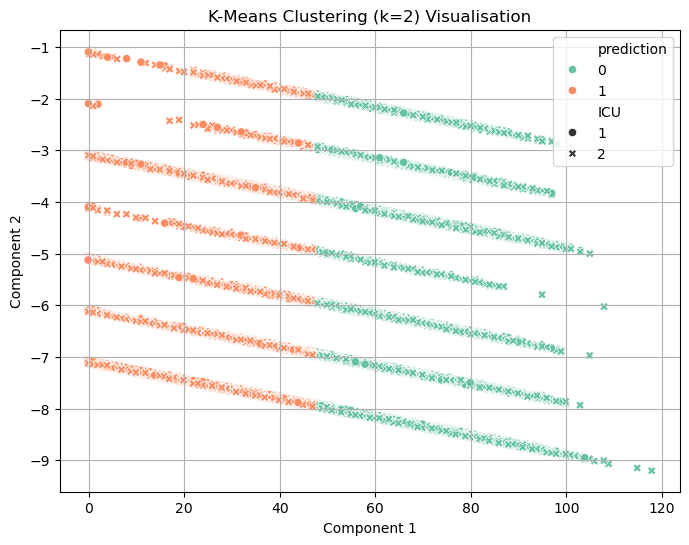

In [221]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='prediction', style='ICU', palette='Set2')
plt.title("K-Means Clustering (k=2) Visualisation")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

In [225]:
cluster_0 = clustered.filter(col("prediction") == 0)
cluster_1 = clustered.filter(col("prediction") == 1)

In [251]:
assembler = VectorAssembler(inputCols=predictors, outputCol="features")
cluster_0 = assembler.transform(cluster_0)

indexer = StringIndexer(inputCol="ICU", outputCol="label")
cluster_0 = indexer.fit(cluster_0).transform(cluster_0)

train_c0, test_c0 = cluster_0.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
model_c0 = rf.fit(train_c0)

In [255]:
prediction_c0_df = prediction_c0.select("label", "prediction", "probability").toPandas()

y_true = prediction_c0_df["label"].astype(int)
y_prediction = prediction_c0_df["prediction"].astype(int)
y_probability = prediction_c0_df["probability"].apply(lambda x: float(x[1]))  

print("Precision:", precision_score(y_true, y_prediction, zero_division=0))
print("Recall:", recall_score(y_true, y_prediction, zero_division=0))
print("F1 Score:", f1_score(y_true, y_prediction, zero_division=0))
print("Cluster 0 AUC Score:", roc_auc_score(y_true, y_probability))

Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Cluster 0 AUC Score: 0.7680211367305095


In [281]:
assembler = VectorAssembler(inputCols=predictors, outputCol="features")
cluster_1 = assembler.transform(cluster_1)

indexer = StringIndexer(inputCol="ICU", outputCol="label")
cluster_1 = indexer.fit(cluster_1).transform(cluster_1)

train_c1, test_c1 = cluster_1.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)
model_c1 = rf.fit(train_c1)

In [285]:
prediction_c1 = model_c1.transform(test_c1)
prediction_c1_df = prediction_c1.select("label", "prediction", "probability").toPandas()

y_true = prediction_c1_df["label"].astype(int)
y_prediction = prediction_c1_df["prediction"].astype(int)
y_probability = prediction_c1_df["probability"].apply(lambda x: float(x[1]))  

print("Precision:", precision_score(y_true, y_prediction, zero_division=0))
print("Recall:", recall_score(y_true, y_prediction, zero_division=0))
print("F1 Score:", f1_score(y_true, y_prediction, zero_division=0))
print("Cluster 1 AUC Score:", roc_auc_score(y_true, y_probability))

Precision: 0.6363636363636364
Recall: 0.005794701986754967
F1 Score: 0.011484823625922888
Cluster 1 AUC Score: 0.797628907222035


In [287]:
final_predictors = ['INTUBED', 'PNEUMONIA', 'INMSUPR', 'OBESITY', 'AGE', 'CLASIFFICATION_FINAL']
label = 'ICU'

In [289]:
assembler = VectorAssembler(inputCols=predictors, outputCol="features")
df_model = assembler.transform(df)

In [291]:
indexer = StringIndexer(inputCol="ICU", outputCol="label")
df_model = indexer.fit(df_model).transform(df_model)

In [293]:
total = df_model.count()
positive = df_model.filter(col("label") == 1).count()
negative = df_model.filter(col("label") == 0).count()
balancing_ratio = negative / (positive + negative)
print(f"Balancing Ratio: {balancing_ratio:.4f}")

df_weighted = df_model.withColumn("classWeightCol", when(col("label") == 1, balancing_ratio).otherwise(1.0))

Balancing Ratio: 0.9157


In [295]:
train_data, test_data = df_weighted.randomSplit([0.8, 0.2], seed=42)

In [297]:
rf_balanced = RandomForestClassifier(featuresCol="features", labelCol="label", weightCol="classWeightCol", numTrees=100)
rf_balanced_model = rf_balanced.fit(train_data)

In [301]:
rf_balanced_prediction = rf_balanced_model.transform(test_data)

rf_df = rf_balanced_prediction.select("label", "prediction", "probability").toPandas()
rf_df['y_true'] = rf_df['label'].astype(int)
rf_df['y_prediction'] = rf_df['prediction'].astype(int)
rf_df['y_probability'] = rf_df['probability'].apply(lambda x: float(x[1]))

print("Precision:", precision_score(rf_df['y_true'], rf_df['y_prediction'], zero_division=0))
print("Recall:", recall_score(rf_df['y_true'], rf_df['y_prediction'], zero_division=0))
print("F1 Score:", f1_score(rf_df['y_true'], rf_df['y_prediction'], zero_division=0))
print("AUC Score:", roc_auc_score(rf_df['y_true'], rf_df['y_probability']))

Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC Score: 0.7771331940489862
